# Exploratory Data Analysis (EDA) — Global Findex Database 2025

## Purpose
This notebook performs exploratory data analysis on the `GlobalFindexDatabase2025.csv` file for a course project.

The source file contains not only country‑specific data but also indicator values for demographic groups (gender, age, education, income, type of settlement, etc.). For cross‑country analysis, the main level of observation is highlighted below: **one country = one row**, with the conditions `year = 2024`, `group = all`, `group2 = all`.

### Key indicators for analysis
- `account_t_d` — the overall level of financial account ownership;
- `mobileaccount_t_d` — ownership of a mobile money account;
- `dig_acc` — use of a digital financial account;
- `merchant_pay` — use of digital payments to merchants;
- `fin4_d` — an indicator related to the use of digital financial services;
- `internet` — use of the internet..

The values of the shares in the source file are stored in the range **0–1** and are additionally converted into percentages in the visualizations.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid", context="notebook")

FILE = "GlobalFindexDatabase2025.csv"
raw = pd.read_csv(FILE, low_memory=False)
print(f"Original size: {raw.shape[0]:,} rows × {raw.shape[1]:,} columns")

Original size: 8,577 rows × 438 columns


## 1. Первичный обзор исходного файла

In [2]:
display(raw.head())

print("Distribution of observations by years:")
display(raw["year"].value_counts().sort_index().to_frame("n_rows"))

print("Number of countries/economies:", raw["codewb"].nunique())
print("Total duplicates:", raw.duplicated().sum())

,countrynewwb,codewb,year,pop_adult,regionwb24_hi,incomegroupwb24,group,group2,account_t_d,fiaccount_t_d,mobileaccount_t_d,borrow_any_t_d,fin4_d,dig_acc,fin11_2a,fin11a,fin11b,fin11c,fin11f,fin11d,fin11e,fin14a,fin14b,fin14c,fin14d,fin13_1a,fin13_1b,fin26a,fin26b,fin27a,fin27b,fin17f,fin17a_17a1_d,fin17a,fin17b,fin17c,fin22d,fin22e,fin22a_22a1_22g_d,fin22a,fin22a_22g,fin22a_1,fin22b,fin22c,fin24sav,fin24fam,fin24work,fin24bor,fin24sell,fin24other,...,con17a_s,con17b_s,con18_s,con19_s,con20_s,con21_s,con26d_s,con27_s,con28m_s,con30a_s,con30b_s,con30c_s,con30d_s,con30e_s,con30f_s,con30g_s,con30h_s,con31a_s,con31b_s,con31f_s,con2a_s,con15_s,con17d_s,con29_s,con31d_s,con31h_s,con32a_s,con3a_s,con4_s,con28d_s,con28w_s,con23_s,con31c_s,con2b_s,con2d_s,con26w_s,con2c_s,con2e_s,con2g_s,con5b_s,con12m_s,con26lm_s,con12w_s,con2f_s,con13_s,con26m_s,con28lm_s,con5a_s,con17c_s,con32h_s
0,Afghanistan,AFG,2011,14575546.0,South Asia (excluding high income),Low income,all,all,0.090050,0.090050,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.028194,0.028194,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Albania,ALB,2011,2281010.0,Europe & Central Asia (excluding high income),Upper middle income,all,all,0.282681,0.282681,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.085616,0.085616,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Algeria,DZA,2011,26251587.0,Middle East & North Africa (excluding high inc...,Lower middle income,all,all,0.332861,0.332861,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.043257,0.043257,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Angola,AGO,2011,12779501.0,Sub-Saharan Africa (excluding high income),Lower middle income,all,all,0.392035,0.392035,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.159156,0.159156,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Argentina,ARG,2011,30685516.0,Latin America & Caribbean (excluding high income),Upper middle income,all,all,0.331302,0.331302,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.038007,0.038007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Distribution of observations by years:


,n_rows
year,
2011,1516
2014,1686
2017,1734
2021,1483
2022,176
2024,1982


Number of countries/economies: 174
Total duplicates: 0


### Conclusion on the structure
The file is a **panel and multidimensional dataset**: countries are repeated across years and socio‑demographic groups. Therefore, using all 8,577 rows simultaneously to compare countries would be incorrect: the same country appears several times.

## 2. Формирование аналитической выборки 2024 года

In [3]:
df = raw.query("year == 2024 and group == 'all' and group2 == 'all'").copy()

print(f"Size of the analytical sample: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Number of unique countries/economies: {df['codewb'].nunique()}")
print(f"Number of duplicate country codes: {df['codewb'].duplicated().sum()}")

display(df[["countrynewwb", "codewb", "year", "regionwb24_hi", "incomegroupwb24"]].head())

Size of the analytical sample: 153 rows × 438 columns
Number of unique countries/economies: 153
Number of duplicate country codes: 0


,countrynewwb,codewb,year,regionwb24_hi,incomegroupwb24
571,Albania,ALB,2024,Europe & Central Asia (excluding high income),Upper middle income
572,Algeria,DZA,2024,Middle East & North Africa (excluding high inc...,Lower middle income
573,Argentina,ARG,2024,Latin America & Caribbean (excluding high income),Upper middle income
574,Armenia,ARM,2024,Europe & Central Asia (excluding high income),Upper middle income
575,Australia,AUS,2024,High income,High income


## 3. Dataset overview: ключевые характеристики

In [4]:
overview = pd.DataFrame({
    "Feature": ["countrynewwb", "codewb", "year", "pop_adult", "regionwb24_hi", "incomegroupwb24"],
    "Description": [
        "Country or economy name",
        "Three-letter World Bank code",
        "Year of observation",
        "Adult population count",
        "Regional classification by World Bank",
        "Income group classification by World Bank"
    ],
    "Type": ["categorical", "categorical", "numeric", "numeric", "categorical", "categorical"]
})
display(overview)

print("Data types:")
display(df.dtypes.value_counts().to_frame("n_columns"))

,Feature,Description,Type
0,countrynewwb,Country or economy name,categorical
1,codewb,Three-letter World Bank code,categorical
2,year,Year of observation,numeric
3,pop_adult,Adult population count,numeric
4,regionwb24_hi,Regional classification by World Bank,categorical
5,incomegroupwb24,Income group classification by World Bank,categorical


Data types:


,n_columns
float64,431
object,6
int64,1


## 4. Анализ качества данных

In [5]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100,
    "non_null_count": df.notna().sum()
}).sort_values("missing_pct", ascending=False)

print("Top-20 features with the highest number of missing values:")
display(missing.head(20))

print("Number of features without missing values:", (missing["missing_count"] == 0).sum())
print("Number of features with missing values:", (missing["missing_count"] > 0).sum())

Top-20 features with the highest number of missing values:


,missing_count,missing_pct,non_null_count
fin32_33_34c_s,153,100.000000,0
fin37_39d_s,153,100.000000,0
fing2p_card_s,153,100.000000,0
fin32_n33_34d_s,153,100.000000,0
fin32_33_34d_s,153,100.000000,0
fin37_38_39d_s,153,100.000000,0
fin34d_s,153,100.000000,0
con12m_s,152,99.346405,1
fin32_33_34b_s,152,99.346405,1
con32h_s,152,99.346405,1


Number of features without missing values: 10
Number of features with missing values: 428


,missing_count,missing_pct,non_null_count
account_t_d,0,0.000000,153
internet,0,0.000000,153
dig_acc,45,29.411765,108
merchant_pay,45,29.411765,108
fin4_d,45,29.411765,108
mobileaccount_t_d,60,39.215686,93


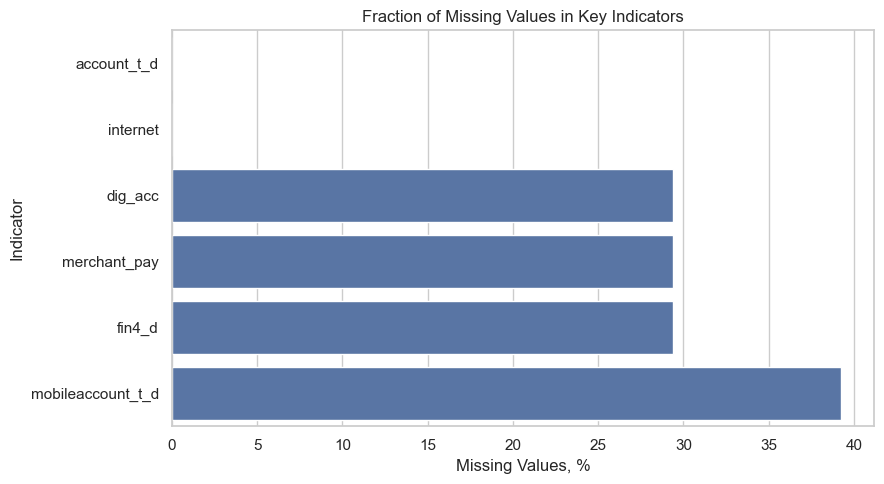

In [6]:
# Пропуски среди наиболее релевантных переменных
key_cols = ["account_t_d", "mobileaccount_t_d", "dig_acc", "merchant_pay", "fin4_d", "internet"]
key_cols = [c for c in key_cols if c in df.columns]

miss_key = missing.loc[key_cols].sort_values("missing_pct")
display(miss_key)

plt.figure(figsize=(9, 5))
sns.barplot(data=miss_key.reset_index(), x="missing_pct", y="index")
plt.title("Fraction of Missing Values in Key Indicators")
plt.xlabel("Missing Values, %")
plt.ylabel("Indicator")
plt.tight_layout()
plt.show()

## 5. Описательная статистика ключевых показателей

In [7]:
key_desc = df[key_cols].describe().T
key_desc["median"] = df[key_cols].median()
key_desc["missing_pct"] = df[key_cols].isna().mean() * 100

# Перевод долей в проценты для удобства интерпретации
for c in ["mean", "std", "min", "25%", "50%", "median", "75%", "max"]:
    if c in key_desc.columns:
        key_desc[c] = key_desc[c] * 100

display(key_desc.round(2))

,count,mean,std,min,25%,50%,75%,max,median,missing_pct
account_t_d,153.0,70.72,22.30,14.83,54.52,73.10,89.60,99.85,73.10,0.00
mobileaccount_t_d,93.0,30.80,20.24,2.65,13.10,28.80,47.40,87.50,28.80,39.22
dig_acc,108.0,46.58,21.22,7.43,29.17,47.66,62.05,96.20,47.66,29.41
merchant_pay,108.0,28.44,22.26,2.42,9.97,20.40,44.28,94.94,20.40,29.41
fin4_d,108.0,29.98,20.71,1.83,11.56,24.44,44.71,73.20,24.44,29.41
internet,153.0,73.20,23.22,11.06,59.78,82.91,90.23,99.12,82.91,0.00


### Interpretation
For percentage indicators, the mean characterizes the typical level of service distribution among countries, the median is less sensitive to extreme values, and the difference between the minimum and maximum values indicates international heterogeneity.

## 6. Распределения ключевых показателей

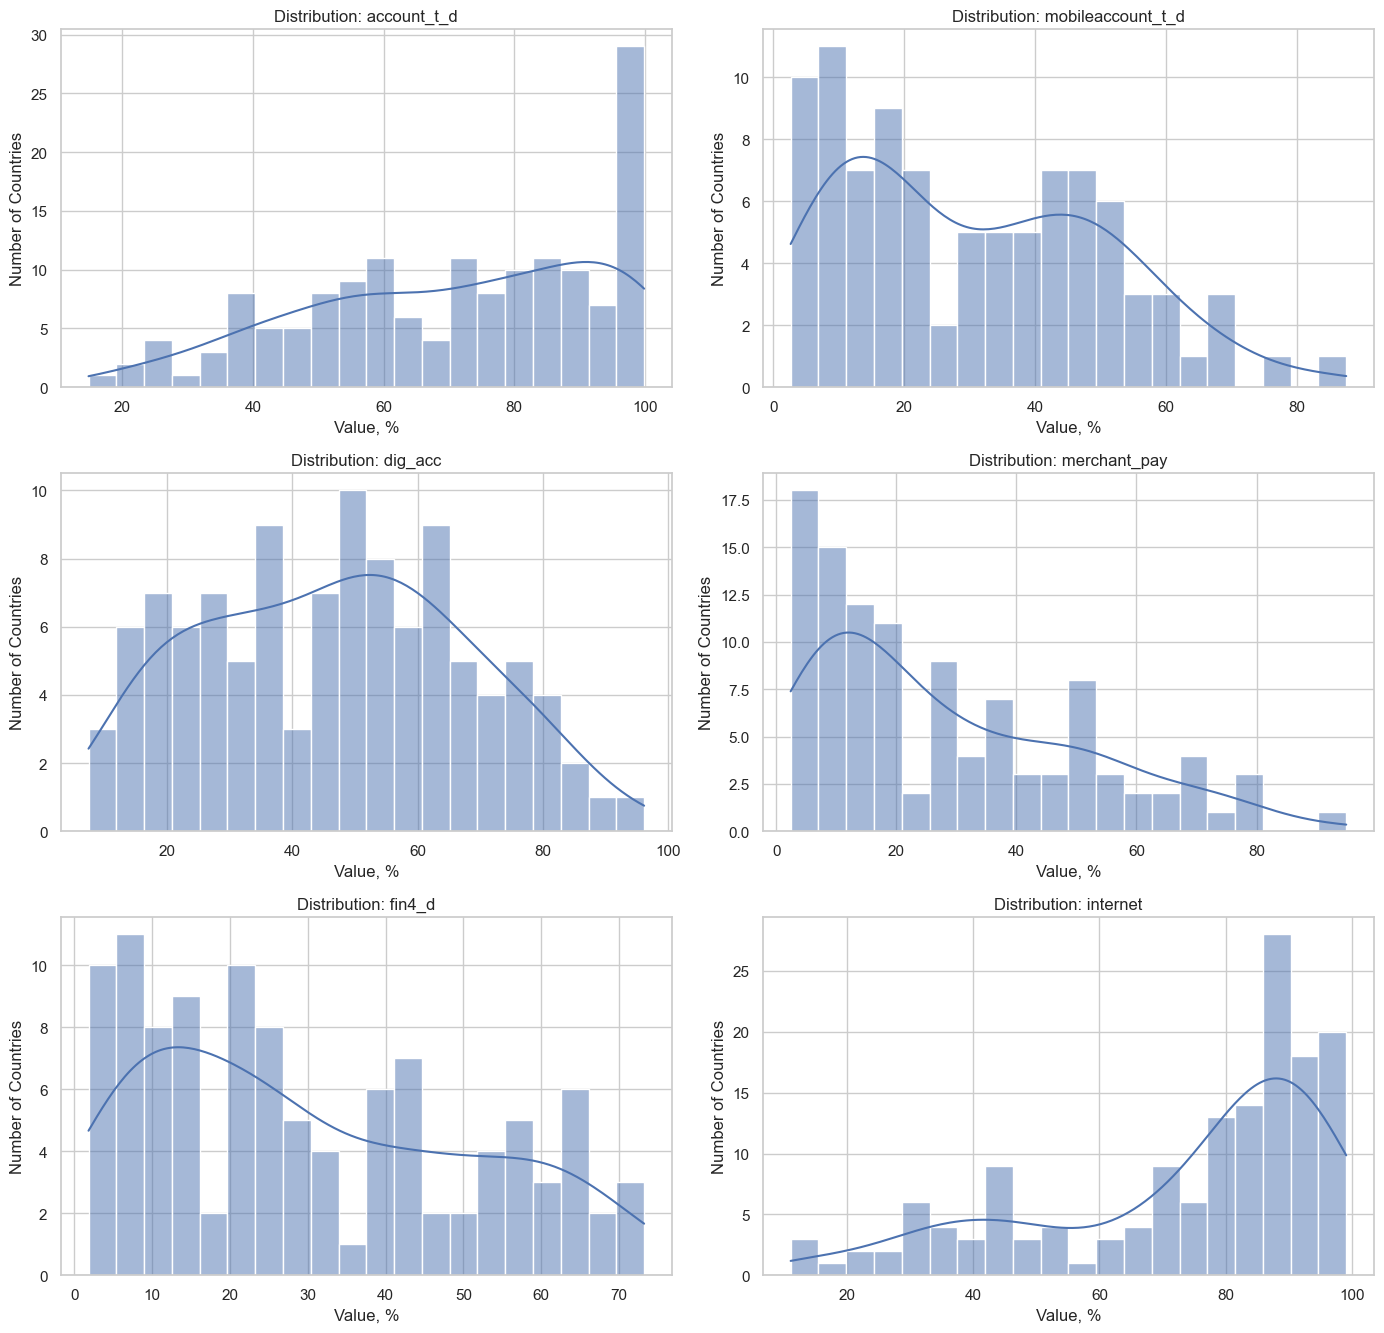

In [8]:
plot_df = df[key_cols].copy() * 100
ncols = 2
nrows = int(np.ceil(len(key_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5 * nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, key_cols):
    sns.histplot(plot_df[col].dropna(), bins=20, kde=True, ax=ax)
    ax.set_title(f"Distribution: {col}")
    ax.set_xlabel("Value, %")
    ax.set_ylabel("Number of Countries")

for ax in axes[len(key_cols):]:
    ax.remove()

plt.tight_layout()
plt.show()

## 7. Boxplot-анализ и потенциальные выбросы

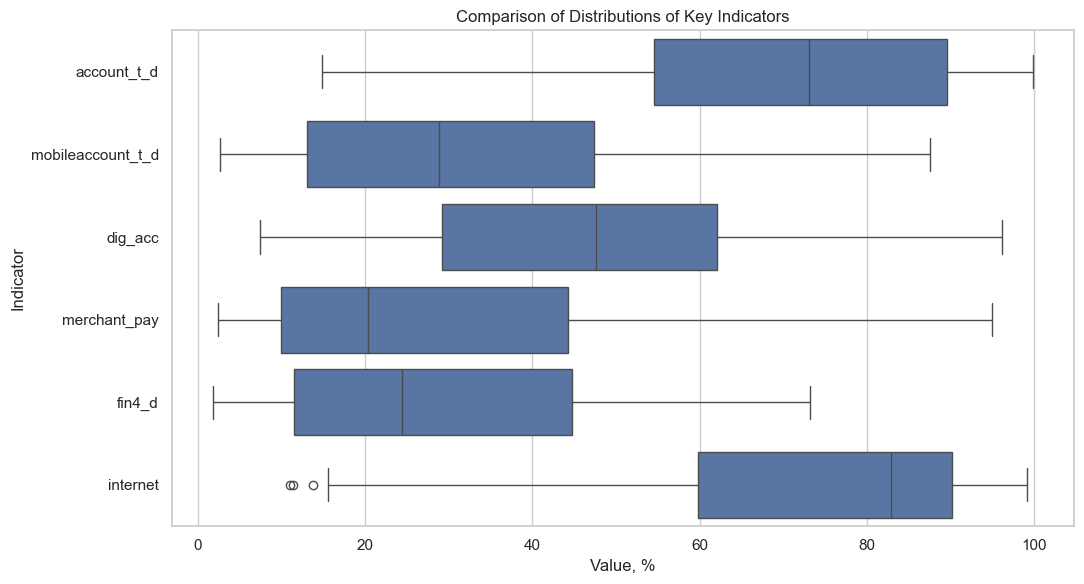

In [9]:
long_df = plot_df.melt(var_name="feature", value_name="value").dropna()
plt.figure(figsize=(11, 6))
sns.boxplot(data=long_df, x="value", y="feature")
plt.title("Comparison of Distributions of Key Indicators")
plt.xlabel("Value, %")
plt.ylabel("Indicator")
plt.tight_layout()
plt.show()

Boxplot is not used here to automatically remove outliers. For cross‑country data, very high or low values often reflect real differences between countries, not data errors.

## 8. Анализ региональной структуры

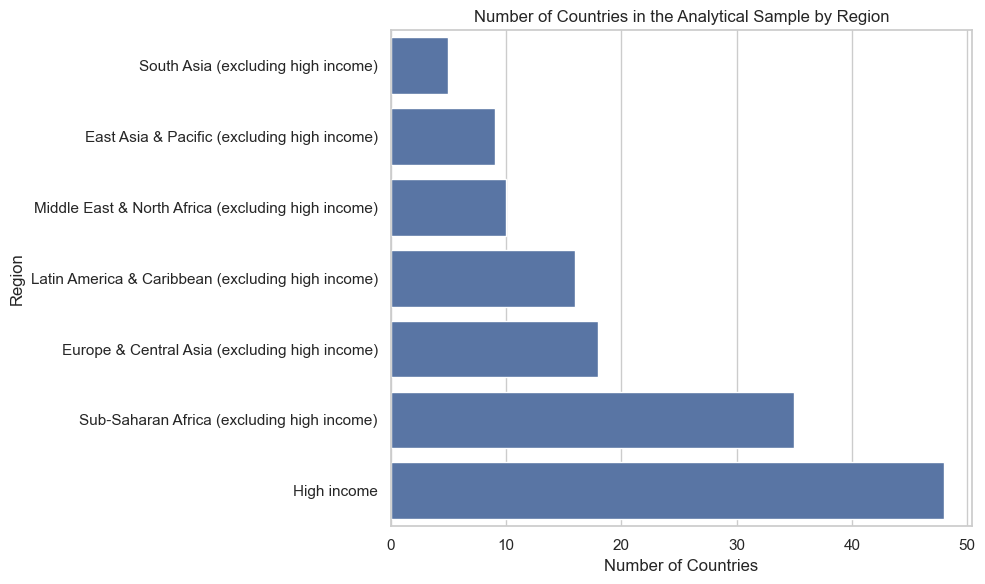

,n_countries
regionwb24_hi,
South Asia (excluding high income),5
East Asia & Pacific (excluding high income),9
Middle East & North Africa (excluding high income),10
Latin America & Caribbean (excluding high income),16
Europe & Central Asia (excluding high income),18
Sub-Saharan Africa (excluding high income),35
High income,48


In [10]:
region_counts = df["regionwb24_hi"].value_counts().sort_values()
plt.figure(figsize=(10, 6))
sns.barplot(x=region_counts.values, y=region_counts.index)
plt.title("Number of Countries in the Analytical Sample by Region")
plt.xlabel("Number of Countries")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

display(region_counts.to_frame("n_countries"))

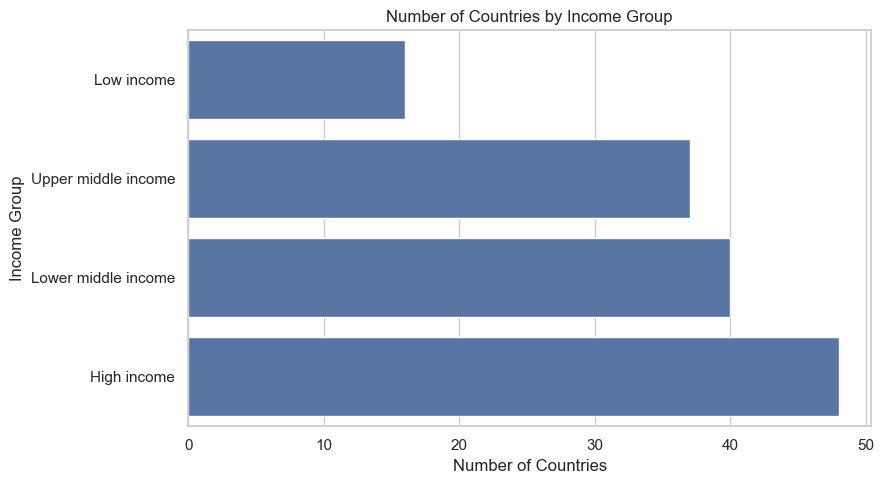

In [11]:
income_counts = df["incomegroupwb24"].value_counts().sort_values()
plt.figure(figsize=(9, 5))
sns.barplot(x=income_counts.values, y=income_counts.index)
plt.title("Number of Countries by Income Group")
plt.xlabel("Number of Countries")
plt.ylabel("Income Group")
plt.tight_layout()
plt.show()

## 9. Сравнение ключевых показателей по регионам

,account_t_d,mobileaccount_t_d,dig_acc,merchant_pay,fin4_d,internet
regionwb24_hi,,,,,,
South Asia (excluding high income),60.26,15.16,25.15,9.88,23.70,43.62
Middle East & North Africa (excluding high income),42.41,9.82,25.41,15.57,21.97,78.23
Latin America & Caribbean (excluding high income),59.93,24.44,42.84,29.65,32.45,81.99
Sub-Saharan Africa (excluding high income),55.60,43.13,48.31,17.25,12.78,41.33
Europe & Central Asia (excluding high income),72.19,23.47,50.52,40.98,50.51,84.20
East Asia & Pacific (excluding high income),69.10,33.56,56.28,44.17,42.89,80.67
High income,91.64,47.01,67.14,55.55,52.91,91.62


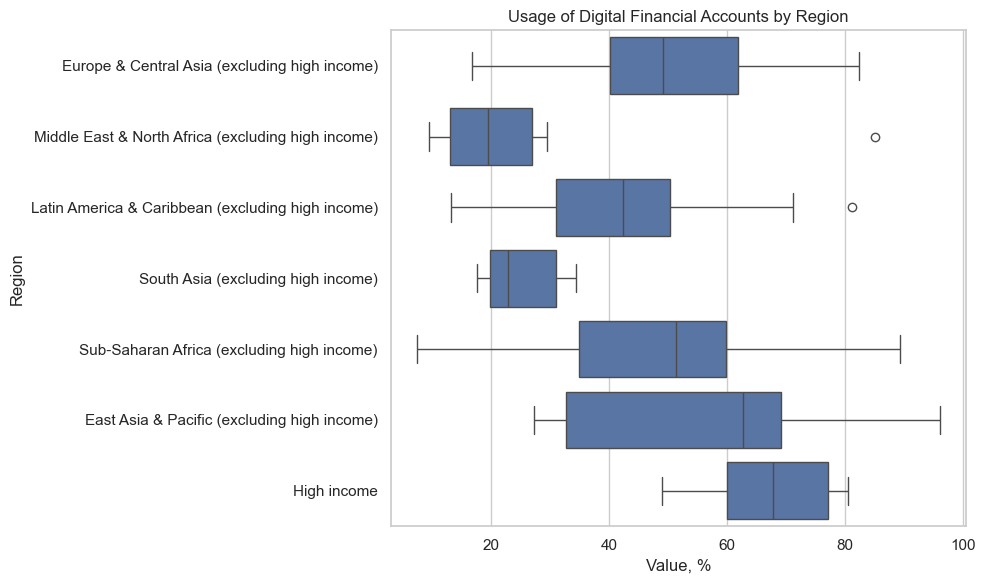

In [12]:
region_metrics = df.groupby("regionwb24_hi")[key_cols].mean() * 100
region_metrics = region_metrics.sort_values("dig_acc") if "dig_acc" in region_metrics else region_metrics
display(region_metrics.round(2))

if "dig_acc" in df.columns:
    plt.figure(figsize=(10, 6))
    temp = df[["regionwb24_hi", "dig_acc"]].dropna().copy()
    temp["dig_acc"] *= 100
    sns.boxplot(data=temp, x="dig_acc", y="regionwb24_hi")
    plt.title("Usage of Digital Financial Accounts by Region")
    plt.xlabel("Value, %")
    plt.ylabel("Region")
    plt.tight_layout()
    plt.show()

## 10. Сравнение показателей по уровню дохода страны

,account_t_d,mobileaccount_t_d,dig_acc,merchant_pay,fin4_d,internet
incomegroupwb24,,,,,,
High income,91.64,47.01,67.14,55.55,52.91,91.62
Low income,45.45,36.14,38.42,8.89,6.23,30.70
Lower middle income,56.34,29.97,41.55,21.98,22.06,62.31
Upper middle income,69.48,30.80,51.23,37.67,43.53,81.54


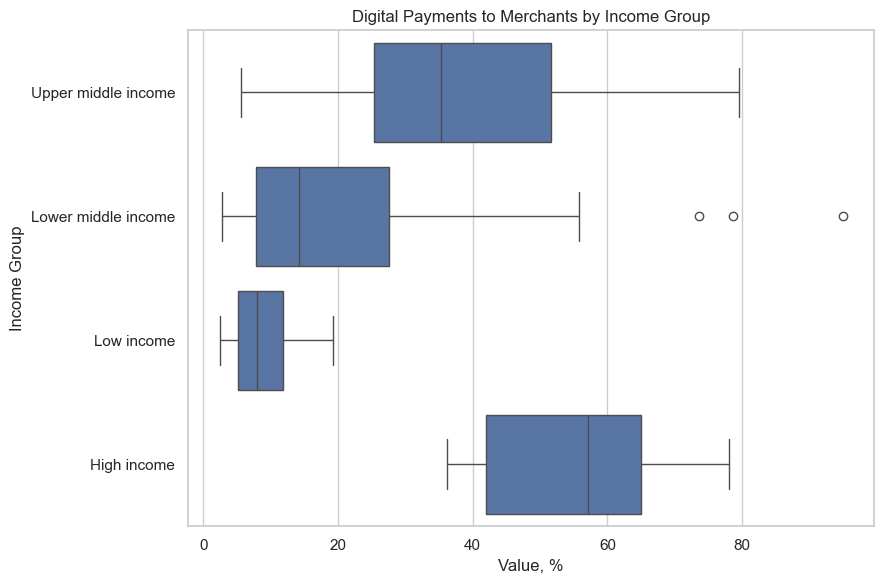

In [13]:
income_metrics = df.groupby("incomegroupwb24")[key_cols].mean() * 100
display(income_metrics.round(2))

if "merchant_pay" in df.columns:
    temp = df[["incomegroupwb24", "merchant_pay"]].dropna().copy()
    temp["merchant_pay"] *= 100
    plt.figure(figsize=(9, 6))
    sns.boxplot(data=temp, x="merchant_pay", y="incomegroupwb24")
    plt.title("Digital Payments to Merchants by Income Group")
    plt.xlabel("Value, %")
    plt.ylabel("Income Group")
    plt.tight_layout()
    plt.show()

## 11. Корреляционный анализ

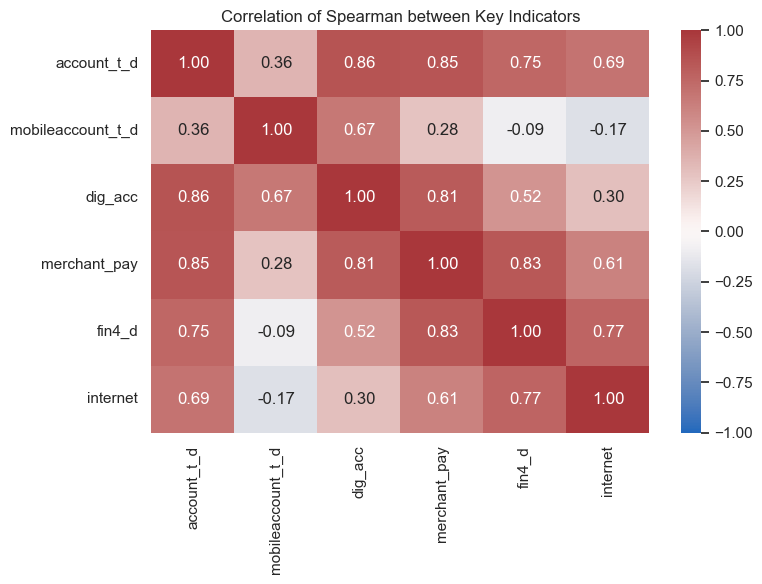

spearman_correlation
account_t_d       dig_acc                   0.855612
                  merchant_pay              0.845380
merchant_pay      fin4_d                    0.830709
dig_acc           merchant_pay              0.812970
fin4_d            internet                  0.765822
account_t_d       fin4_d                    0.753246
                  internet                  0.690533
mobileaccount_t_d dig_acc                   0.671484
merchant_pay      internet                  0.610659
dig_acc           fin4_d                    0.520116

In [14]:
corr_data = df[key_cols].copy()
corr = corr_data.corr(method="spearman")

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", center=0, cmap="vlag", vmin=-1, vmax=1)
plt.title("Correlation of Spearman between Key Indicators")
plt.tight_layout()
plt.show()

# Сильнейшие пары
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
pairs = pairs.reindex(pairs.abs().sort_values(ascending=False).index)
display(pairs.head(10).to_frame("spearman_correlation"))

## 12. Связь цифровой инфраструктуры и цифровых финансов

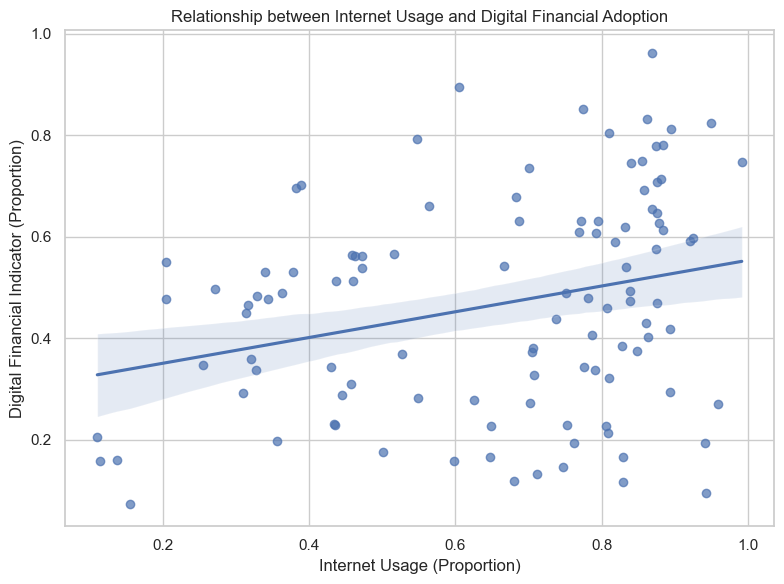

Spearman Correlation: 0.305


In [15]:
# Scatter plot: internet vs digital financial adoption
if "internet" in df.columns and "dig_acc" in df.columns:
    temp = df[["countrynewwb", "internet", "dig_acc"]].dropna().copy()
    plt.figure(figsize=(8, 6))
    sns.regplot(data=temp, x="internet", y="dig_acc", scatter_kws={"alpha": 0.7})
    plt.title("Relationship between Internet Usage and Digital Financial Adoption")
    plt.xlabel("Internet Usage (Proportion)")
    plt.ylabel("Digital Financial Indicator (Proportion)")
    plt.tight_layout()
    plt.show()
    print("Spearman Correlation:", temp[["internet", "dig_acc"]].corr(method="spearman").iloc[0, 1].round(3))

## 13. Рейтинг стран по ключевому цифровому показателю

,countrynewwb,regionwb24_hi,dig_acc
657,Mongolia,East Asia & Pacific (excluding high income),0.962049
636,Kenya,Sub-Saharan Africa (excluding high income),0.894039
628,"Iran, Islamic Rep.",Middle East & North Africa (excluding high inc...,0.851176
594,China,East Asia & Pacific (excluding high income),0.832148
701,Ukraine,Europe & Central Asia (excluding high income),0.823869
707,"Venezuela, RB",Latin America & Caribbean (excluding high income),0.811894
676,Poland,High income,0.805034
618,Ghana,Sub-Saharan Africa (excluding high income),0.792805
635,Kazakhstan,Europe & Central Asia (excluding high income),0.779810
601,Croatia,High income,0.779412


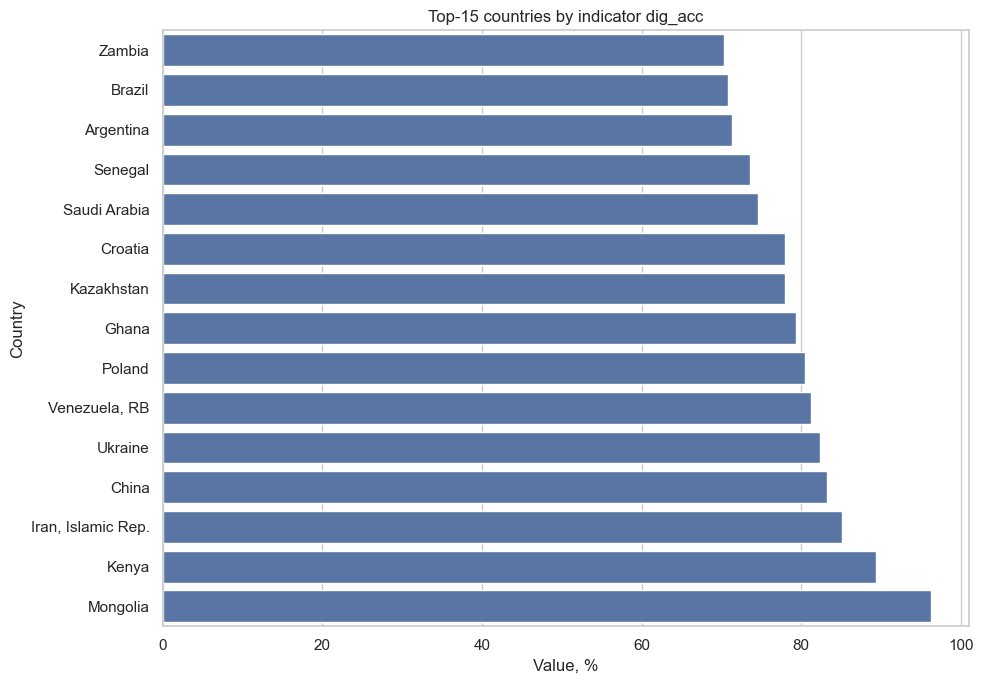

In [16]:
RANK_COL = "dig_acc" if "dig_acc" in df.columns else key_cols[0]
rank = df[["countrynewwb", "regionwb24_hi", RANK_COL]].dropna().sort_values(RANK_COL, ascending=False)
rank_pct = rank.head(15).sort_values(RANK_COL).copy()
rank_pct[RANK_COL] *= 100

display(rank.head(15))

plt.figure(figsize=(10, 7))
sns.barplot(data=rank_pct, x=RANK_COL, y="countrynewwb")
plt.title(f"Top-15 countries by indicator {RANK_COL}")
plt.xlabel("Value, %")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

## 14. Итоговые выводы для курсового проекта

In [17]:
print("Main Characteristics of the Analytical Sample")
print("- Countries/ Economies:", df["codewb"].nunique())
print("- Year:", df["year"].unique())
print("- Columns in the original file:", raw.shape[1])
print("- Rows after filtering to country-level:", len(df))
print("- Complete duplicates after filtering:", df.duplicated().sum())

print("\nAverage Values of Key Indicators, %:")
print((df[key_cols].mean()*100).sort_values(ascending=False).round(2))

Main Characteristics of the Analytical Sample
- Countries/ Economies: 153
- Year: [2024]
- Columns in the original file: 438
- Rows after filtering to country-level: 153
- Complete duplicates after filtering: 0

Average Values of Key Indicators, %:
internet             73.20
account_t_d          70.72
dig_acc              46.58
mobileaccount_t_d    30.80
fin4_d               29.98
merchant_pay         28.44
dtype: float64


1. **Main analytical unit:** country/economy in 2024.
2. **Main digital indicators:** `dig_acc`, `merchant_pay`, `mobileaccount_t_d` and other indicators of digital financial behavior.
3. **Contextual indicators:** `internet`, region and income group.
4.Before combining with the Economic Freedom Index: it is necessary to standardize the names or use three‑letter country codes (`codewb`).
5. **Next step:** select 1 main FinTech metric, combine the country‑level sample with the Economic Freedom Index, and check the statistical relationship using a scatter plot, correlation, and regression analysis.